In [3]:
#### Final Project - Mohan Kumar Paramasivan - Dataset 3 ####
#### The Rice Grains Dataset ####
#### Algorithm 1 - Neural Networks ####
#### Extra Credit Question 1 ####

import pandas as pd
import numpy as np

np.set_printoptions(precision=5, suppress=True, floatmode='fixed')

#### Sigmoid Function ####
def sigmoid(z):
    return (1 / (1 + np.exp(-z)))

#### Forward Propagation Function ####
def forward_propagation(x, y, Thetas, instance_num, verbose=False):
    if verbose: print(f"\tProcessing training instance {instance_num}")
    if verbose: print(f"\tForward propagating the input {x}")

    a = np.concatenate(([1.0], x))
    neuron = [a]
    if verbose: print(f"a1:", a)
    
    for i, Theta in enumerate(Thetas):
        z = Theta @ a
        if verbose: print(f"z{i+2}:", z)
        a = sigmoid(z)
        if i < len(Thetas) - 1:
            a = np.concatenate(([1.0], a))
        if verbose: print(f"a{i+2}:", a)
        neuron.append(a)

    fx = neuron[-1]
    J = float(np.sum((-y * np.log(fx)) - ((1-y) * np.log(1-fx))))

    ##print(f"a{i+2}:", a)
    if verbose: print("f(x):", neuron[-1])
    if verbose: print(f"Predicted output for instance {instance_num}:", neuron[-1])
    if verbose: print(f"Expected output for instance {instance_num}:", y)
    if verbose: print(f"Cost, J, associated with instance {instance_num}: {round(J, 3)}\n")
    return neuron, J        

#### Cost Function ####
def cost_function(J_list, Thetas, lambda_, verbose=False):
    n = len(J_list)
    reg = (lambda_/(2 * n)) * sum(np.sum(Theta[:, 1:] ** 2) for Theta in Thetas)
    J_final = (sum(J_list)/n) + reg
    if verbose: print(f"Final (regularized) cost, J, based on the complete training set:{round(J_final, 5)}")
    return J_final 

#### Back Propagation function ####
def back_propagation(neuron, y, Thetas, instance_num, verbose=False):

    deltas = []
    gradients = []

    if verbose: print(f"Computing gradients based on training instance {instance_num}:")
    fx = neuron[-1]
    delta_output = fx - y
    deltas.append(delta_output)
    if verbose: print(f'Delta{len(neuron)}:', delta_output)       
 
    for i in range(len(Thetas) - 1, 0, -1):
        propagate = Thetas[i].T @ deltas[-1]
        propagate_no_bias = propagate[1:]
        a = neuron[i][1:]
        delta_hidden = propagate_no_bias * a * (1 - a)
        deltas.append(delta_hidden)
        if verbose: print(f'Delta{i+1}:', delta_hidden)
    deltas.reverse()

    # Gradients
    for i in range(len(Thetas)):
        grad = np.outer(deltas[i], neuron[i])
        gradients.append(grad)
        if verbose: print(f'Gradients of Theta{i+1} based on training instance {instance_num}:\n', grad)

    return gradients


#### Regularized Gradients Function ####
def regularized_gradients(all_instance_gradients, Thetas, lambda_, verbose=False):
    n = len(all_instance_gradients)
    Final_Gradients = []
    
    for i in range(len(Thetas)):
        # Sum gradients across all instances
        total_grad = sum(grads[i] for grads in all_instance_gradients)
        
        # Build regularization matrix (skip bias column)
        reg = np.zeros_like(Thetas[i])
        reg[:, 1:] = Thetas[i][:, 1:]
        
        # Average + regularize
        final_grad = (total_grad / n) + (lambda_ / n) * reg
        Final_Gradients.append(final_grad)
        if verbose: print(f'Final regularized gradients of Theta{i+1}:\n', final_grad)
    
    return Final_Gradients

In [5]:
#### Final Project - Mohan Kumar Paramasivan - Dataset 3 ####
#### The Rice Grains Dataset ####
#### Algorithm 1 - Neural Networks ####
#### Extra Credit Question 1 ####

def adjust_all_weights(Thetas, Final_Gradients, alpha, verbose=False):
    adjusted_Thetas = []
    for i in range(len(Thetas)):
        new_Theta = Thetas[i] - alpha * Final_Gradients[i]
        adjusted_Thetas.append(new_Theta)
        if verbose: print(f'Updated Theta{i+1}:\n', new_Theta)
    return adjusted_Thetas

In [7]:
#### Final Project - Mohan Kumar Paramasivan - Dataset 3 ####
#### The Rice Grains Dataset ####
#### Algorithm 1 - Neural Networks ####
#### Extra Credit Question 1 ####

def train(X, Y, Thetas, alpha, lambda_, m=1000):
    for iteration in range(m):
        all_instance_gradients = []
        J_list = []
        all_neurons = []
        
        for i, (x, y) in enumerate(zip(X, Y)):
            result, J = forward_propagation(x, y, Thetas, i+1, verbose=False)
            J_list.append(float(J))
            all_neurons.append(result)
        
        current_J = cost_function(J_list, Thetas, lambda_, verbose=False)
        
        for i, (x, y) in enumerate(zip(X, Y)):
            grads = back_propagation(all_neurons[i], y, Thetas, i+1, verbose=False)
            all_instance_gradients.append(grads)
        
        Final_Gradients = regularized_gradients(all_instance_gradients, Thetas, lambda_, verbose=False)
        Thetas = adjust_all_weights(Thetas, Final_Gradients, alpha, verbose=False)

        if (iteration + 1) % 1000 == 0:
            print(f'Iteration {iteration+1}: J = {current_J:.6f}')
    
    return Thetas

In [9]:
#### Final Project - Mohan Kumar Paramasivan - Dataset 3 ####
#### The Rice Grains Dataset ####
#### Algorithm 1 - Neural Networks ####
#### Extra Credit Question 1 ####

#### Normalize function used to normalize the data for each columns between 0 and 1
def normalize(X_train, X_test):
    #### pick the minimum value from each column and assign as X_Min. axis = 0 means pick min value from each columns
    X_Min = X_train.min(axis = 0) 
    #### pick the maximum value from each column and assign as X_Max. axis = 0 means pick max value from each columns
    X_Max = X_train.max(axis = 0)
    #### The difference between X_Max and X_Min is used as the denominator for the normalize formula calculation
    denominator = (X_Max - X_Min)
    #### To avoid dividing by zero, replace 0 values in the denominator with 1
    denominator[denominator == 0] = 1 
    #### Each value in the column is normalized with the Normalization formula : (X - X_Min) / (X_Max - X_Min)
    X_train_norm = ((X_train - X_Min) / denominator)
    #### The testing dataset is normalized using the training dataset
    X_test_norm = ((X_test - X_Min) / denominator)
    return X_train_norm, X_test_norm
    #### returns the normalized value for the training and test set

In [11]:
#### Final Project - Mohan Kumar Paramasivan - Dataset 3 ####
#### The Rice Grains Dataset ####
#### Algorithm 1 - Neural Networks ####
#### Extra Credit Question 1 ####

#### Added in HW 3 ####
def create_stratified_folds(X, y, k=5):

    labels = np.unique(y)
    #### np.unique(y) - returns the unique labels from the dataset
    #### get all unique class labels e.g. for WDBC dataset it returns ['Benign', 'Malignant']

    folds = [[] for i in range(k)]
    #### create k empty lists e.g. [[], [], [], [], []]

    for label in labels:
        #### handle each label values separately to keep proportions

        label_indices = np.where(y == label)[0]
        #### y == label compares every value in y with the label value and returns True/False for every value of y             
        #### np.where finds positions where condition is True and returns a tuple containing a numpy array e.g. (array([0, 2, 3]),)
        #### [0] returns the numpy array from the tuple e.g. array([0, 2, 3])

        np.random.shuffle(label_indices)
        #### np.random.shuffle(label_indices) randomly shuffles the order of the values in the label_indices array
        #### the original array values will be randomly reshuffled and presented in a different order in the array
        #### array([1,2,3,4]) will be reshuffled to array([3,2,4,1])


        for i, index in enumerate(label_indices):
        #### enumerate returns both the position number (i) and label_indices values (index)
        #### i = position number e.g. 0, 1, 2, 3, 4,...
        #### index = row numbers in label indices values e.g. 3, 2, 4, 1, ...
            folds[i % k].append(index)
            #### i % k provides the remainder values of dividing the position number with k = 5 (no of folds) e.g (i % k) is 0, 1, 2, 3, 4
            #### folds[i % k] assigns each remainder values to each different folds e.g fold 0, fold 1, fold 2, fold 3, fold 4
            #### folds[i % k].append(index) adds the row numbers from label indices to each fold

    #### returns k folds as a list of k lists ####
    #### each fold contains row numbers of instances assigned to that fold
    return folds

In [13]:
#### Final Project - Mohan Kumar Paramasivan - Dataset 3 ####
#### The Rice Grains Dataset ####
#### Algorithm 1 - Neural Networks ####
#### Extra Credit Question 1 ####

#### Added in HW 3 ####
def accuracy(y_true, y_pred):
    y_true = list(y_true)
    y_pred = list(y_pred)
    correct = sum(yt == yp for yt, yp in zip(y_true, y_pred))
    return correct / len(y_true)

def precision(y_true, y_pred, positive_class = 1):

    True_Positive  = 0
    False_Positive = 0

    for ytrue, ypred in zip(y_true, y_pred):
        #### zip() pairs each item from y_true and y_pred ####
        #### for loop iterates through each pair of ytrue and ypred ####
        if ytrue == positive_class and ypred == positive_class:
            True_Positive += 1   
            #### Predicted positive and Actual positive ####
        elif ytrue != positive_class and ypred == positive_class:
            False_Positive += 1  
            #### Predicted positive but Actual negative ####

    if True_Positive + False_Positive == 0:
        #### returns 0 when divided by 0 ####
        return 0.0

    #### precision = True Positive / (True Positive + False Positive) ####
    return True_Positive / (True_Positive + False_Positive)

def recall(y_true, y_pred, positive_class = 1):

    True_Positive  = 0
    False_Negative = 0

    for ytrue, ypred in zip(y_true, y_pred):
        #### zip() pairs each item from y_true and y_pred ####
        #### for loop iterates through each pair of ytrue and ypred ####
        if ytrue == positive_class and ypred == positive_class:
            True_Positive += 1   
            #### Predicted positive and Actual positive ####
        elif ytrue == positive_class and ypred != positive_class:
            False_Negative += 1  
            #### Predicted negative but Actual positive ####

    if True_Positive + False_Negative == 0:
        #### returns 0 when divided by 0 ####
        return 0.0
        
    #### recall = True Positive / (True Positive + False Negative) ####
    return True_Positive / (True_Positive + False_Negative)

def f1_score(y_true, y_pred, positive_class = 1):

    prec = precision(y_true, y_pred, positive_class)
    rec = recall(y_true, y_pred, positive_class)

    if prec + rec == 0:
        #### returns 0 when divided by 0 ####
        return 0.0
        
    #### F1 = 2 * (precision * recall) / (precision + recall) ####  
    return 2 * (prec * rec) / (prec + rec)

In [15]:
#### Final Project - Mohan Kumar Paramasivan - Dataset 3 ####
#### The Rice Grains Dataset ####
#### Algorithm 1 - Neural Networks ####
#### Extra Credit Question 1 ####

def initialize_weights(layer_sizes):
    Thetas = []
    for i in range(len(layer_sizes) - 1):
        Theta = np.random.uniform(-1, 1, (layer_sizes[i+1], layer_sizes[i]+1))  
        #### random.uniform(minimum value, maximum value, shape of the array(rows, columns)
        #### generates random values between -1 and 1
        #### rows = layer_sizes[i+1] : number of neurons in next layer
        #### cols = layer_sizes[i]+1 : number of neurons in current layer + 1 bias
        Thetas.append(Theta)
    return Thetas      

In [17]:
#### Final Project - Mohan Kumar Paramasivan - Dataset 3 ####
#### The Rice Grains Dataset ####
#### Algorithm 1 - Neural Networks ####
#### Extra Credit Question 1 ####

def predict(X, Thetas):
    y_pred = [] ### initialize with empty list
    for x in X:
        neuron, _ = forward_propagation(x, np.array([0.0]), Thetas,0)
        ## Cost function J is ignored
        ## dummy value np.array([0.0]) is used for Y for the forward propagation function
        ## dummy value 0 is used for instance_num for the forward propagation function
        y_pred.append(1 if neuron[-1] >= 0.5 else 0)
    return np.array(y_pred)

In [19]:
#### Final Project - Mohan Kumar Paramasivan - Dataset 3 ####
#### The Rice Grains Dataset ####
#### Algorithm 1 - Neural Networks ####
#### Extra Credit Question 1 ####

def cross_validate_nn(X, y, layer_sizes, alpha, lambda_, m=1000, k=5):
    
    folds = create_stratified_folds(X, y, k)
    #### creates k = 5 stratified folds of the dataset ####
    
    accuracy_scores = []
    f1_scores = []
    #### initial empty list created for accuracy_scores, precision_scores, recall_scores, f1_scores ####

    for i in range(k):
        #### the for loop iterates for each fold ####
        
        test_indices  = np.array(folds[i])
        #### the selected fold is choosen as the test indices ####
        #### the values in the folds are converted in to numpy array ####
        
        train_indices = np.array([idx for j in range(k) if j != i for idx in folds[j]])
        #### for j in range(k) for j != i : it picks the rest of the folds other than the test fold for training indices ####
        #### the values in the folds are converted in to numpy array ####
        
        X_train, y_train = X[train_indices], y[train_indices]
        #### divides the training indices into X_train and y_train ####
        X_test,  y_test  = X[test_indices],  y[test_indices]
        #### divides the testing indices into X_test and y_test ####
        
        X_train, X_test = normalize(X_train, X_test)
        #### normalize the training and testing instances ####
        
        Thetas = initialize_weights(layer_sizes)
        #### assigns random weights to the layers ####
        Thetas = train(X_train, y_train, Thetas, alpha, lambda_, m)
        #### Updates the Thetas based on the interation and reduces the cost function ####
        y_pred = predict(X_test, Thetas)
        #### Predicts the output ####
        
        accuracy_scores.append(accuracy(y_test, y_pred))
        f1_scores.append(f1_score(y_test, y_pred))
        #### calculates and stores metrics for kth fold ####
        
    return {
        'Accuracy': round(float(np.mean(accuracy_scores)), 6),
        'F1 Score': round(float(np.mean(f1_scores)), 6)
    }

In [29]:
#### Final Project - Mohan Kumar Paramasivan - Dataset 3 ####
#### The Rice Grains Dataset ####
#### Algorithm 1 - Neural Networks ####
#### Extra Credit Question 1 ####

import pandas as pd
import numpy as np

rice_dataset = pd.read_csv("C:/Users/mohan/OneDrive/Desktop/UMass Amhers MSCS/Spring 2026 - Machine Learning/Final Project/Final_Project_CMPSCI_589_Spring2026_Supporting_Files/Final_Project_CMPSCI_589_Spring2026_Supporting_Files/rice.csv", header = 0)
rice_dataset = rice_dataset.dropna()

X_Rice = np.array(rice_dataset.drop('label', axis=1), dtype=float)
#### convert string labels to 0 and 1 ####
Y_Rice = np.array([1.0 if label == 'Cammeo' else 0.0 for label in rice_dataset['label']])

print('Rice Dataset shape:', X_Rice.shape, Y_Rice.shape)
print('Number of features:', X_Rice.shape[1])
rice_dataset.head()

Rice Dataset shape: (3810, 7) (3810,)
Number of features: 7


,attr1_num,attr2_num,attr3_num,attr4_num,attr5_num,attr6_num,attr7_num,label
0,15231,525.578979,229.749878,85.093788,0.928882,15617,0.572896,Cammeo
1,14656,494.311005,206.020065,91.730972,0.895405,15072,0.615436,Cammeo
2,14634,501.122009,214.106781,87.768288,0.912118,14954,0.693259,Cammeo
3,13176,458.342987,193.337387,87.448395,0.891861,13368,0.640669,Cammeo
4,14688,507.166992,211.743378,89.312454,0.906691,15262,0.646024,Cammeo


In [37]:
#### Final Project - Mohan Kumar Paramasivan - Dataset 3 ####
#### The Rice Grains Dataset ####
#### Algorithm 1 - Neural Networks ####
#### Extra Credit Question 1 ####

lambdas = [0.1, 0.01]
architectures = [
    [7, 2, 1],           #### one hidden layer, simple network
    [7, 4, 1],
    [7, 8, 1],          #### one hidden layer but many neurons per layer
    [7, 2, 4, 1],
    [7, 4, 8, 1],       #### few layers but many neurons per layer
    [7, 2, 4, 8, 1],    #### adding more layers
    [7, 2, 2, 2, 2, 1]
]

rice_results1 = {}
for layer_sizes in architectures:
    for i in lambdas:
        print(f'\nArchitecture: {layer_sizes}, Lambda: {i}')
        key = f'{layer_sizes}_lambda{i}'
        rice_results1[key] = cross_validate_nn(X_Rice, Y_Rice, layer_sizes, alpha = 0.05, lambda_ = i, m = 1000)
        print(rice_results1[key])


Architecture: [7, 2, 1], Lambda: 0.1
Iteration 1000: J = 0.555683
Iteration 1000: J = 0.641623
Iteration 1000: J = 0.566780
Iteration 1000: J = 0.669222
Iteration 1000: J = 0.656496
{'Accuracy': 0.650394, 'F1 Score': 0.248343}

Architecture: [7, 2, 1], Lambda: 0.01
Iteration 1000: J = 0.566716
Iteration 1000: J = 0.539010
Iteration 1000: J = 0.633214
Iteration 1000: J = 0.657370
Iteration 1000: J = 0.658430
{'Accuracy': 0.665879, 'F1 Score': 0.294247}

Architecture: [7, 4, 1], Lambda: 0.1
Iteration 1000: J = 0.531832
Iteration 1000: J = 0.515274
Iteration 1000: J = 0.522312
Iteration 1000: J = 0.576354
Iteration 1000: J = 0.552624
{'Accuracy': 0.855381, 'F1 Score': 0.799682}

Architecture: [7, 4, 1], Lambda: 0.01
Iteration 1000: J = 0.542883
Iteration 1000: J = 0.568178
Iteration 1000: J = 0.614469
Iteration 1000: J = 0.662502
Iteration 1000: J = 0.455613
{'Accuracy': 0.756955, 'F1 Score': 0.553389}

Architecture: [7, 8, 1], Lambda: 0.1
Iteration 1000: J = 0.512036
Iteration 1000: J =

In [39]:
#### Final Project - Mohan Kumar Paramasivan - Dataset 3 ####
#### The Rice Grains Dataset ####
#### Algorithm 1 - Neural Networks ####
#### Extra Credit Question 1 ####

lambdas = [0.1, 0.01]
architectures = [
    [7, 4, 1],      
    [7, 8, 1],      
    [7, 16, 1],     
    [7, 32, 1],     
    [7, 8, 16, 1]  
    ]

rice_results2 = {}
for layer_sizes in architectures:
    for i in lambdas:
        print(f'\nArchitecture: {layer_sizes}, Lambda: {i}')
        key = f'{layer_sizes}_lambda{i}'
        rice_results2[key] = cross_validate_nn(X_Rice, Y_Rice, layer_sizes, alpha=0.05, lambda_=i, m=2000, k=10)
        print(rice_results2[key])


Architecture: [7, 4, 1], Lambda: 0.1
Iteration 1000: J = 0.567051
Iteration 2000: J = 0.368925
Iteration 1000: J = 0.658192
Iteration 2000: J = 0.537407
Iteration 1000: J = 0.490832
Iteration 2000: J = 0.319000
Iteration 1000: J = 0.665658
Iteration 2000: J = 0.538248
Iteration 1000: J = 0.521804
Iteration 2000: J = 0.337958
Iteration 1000: J = 0.615691
Iteration 2000: J = 0.437051
Iteration 1000: J = 0.593169
Iteration 2000: J = 0.402457
Iteration 1000: J = 0.616115
Iteration 2000: J = 0.431499
Iteration 1000: J = 0.626320
Iteration 2000: J = 0.429736
Iteration 1000: J = 0.582076
Iteration 2000: J = 0.381066
{'Accuracy': 0.899738, 'F1 Score': 0.875839}

Architecture: [7, 4, 1], Lambda: 0.01
Iteration 1000: J = 0.661378
Iteration 2000: J = 0.569616
Iteration 1000: J = 0.577238
Iteration 2000: J = 0.373007
Iteration 1000: J = 0.569511
Iteration 2000: J = 0.371531
Iteration 1000: J = 0.596195
Iteration 2000: J = 0.438654
Iteration 1000: J = 0.573648
Iteration 2000: J = 0.370418
Iteratio

KeyboardInterrupt: 

In [41]:
rice_results2

{'[7, 4, 1]_lambda0.1': {'Accuracy': 0.899738, 'F1 Score': 0.875839},
 '[7, 4, 1]_lambda0.01': {'Accuracy': 0.892651, 'F1 Score': 0.859798},
 '[7, 8, 1]_lambda0.1': {'Accuracy': 0.910761, 'F1 Score': 0.893853},
 '[7, 8, 1]_lambda0.01': {'Accuracy': 0.914698, 'F1 Score': 0.898798},
 '[7, 16, 1]_lambda0.1': {'Accuracy': 0.916798, 'F1 Score': 0.901303},
 '[7, 16, 1]_lambda0.01': {'Accuracy': 0.916273, 'F1 Score': 0.900758},
 '[7, 32, 1]_lambda0.1': {'Accuracy': 0.920735, 'F1 Score': 0.906319},
 '[7, 32, 1]_lambda0.01': {'Accuracy': 0.92126, 'F1 Score': 0.906819},
 '[7, 8, 16, 1]_lambda0.1': {'Accuracy': 0.908399, 'F1 Score': 0.889075},
 '[7, 8, 16, 1]_lambda0.01': {'Accuracy': 0.917848, 'F1 Score': 0.902736}}

Iteration 1000: J = 0.068970
Iteration 2000: J = 0.057023
Size: 5, J: 6.12840
Iteration 1000: J = 0.041574
Iteration 2000: J = 0.037508
Size: 10, J: 6.44745
Iteration 1000: J = 0.024517
Iteration 2000: J = 0.022916
Size: 20, J: 6.52743
Iteration 1000: J = 0.010319
Iteration 2000: J = 0.009397
Size: 50, J: 6.75888
Iteration 1000: J = 0.006261
Iteration 2000: J = 0.005407
Size: 100, J: 6.90120
Iteration 1000: J = 0.003875
Iteration 2000: J = 0.003029
Size: 200, J: 6.44385
Iteration 1000: J = 0.002538
Iteration 2000: J = 0.001726
Size: 500, J: 6.66209
Iteration 1000: J = 0.002169
Iteration 2000: J = 0.001318
Size: 1000, J: 6.23919
Iteration 1000: J = 0.001973
Iteration 2000: J = 0.001125
Size: 1500, J: 6.68916
Iteration 1000: J = 0.263151
Iteration 2000: J = 0.196325
Size: 2000, J: 0.62548
Iteration 1000: J = 0.323507
Iteration 2000: J = 0.236398
Size: 2500, J: 0.38948
Iteration 1000: J = 0.355364
Iteration 2000: J = 0.250543
Size: 3000, J: 0.30611
Iteration 1000: J = 0.350103
Iteration 2

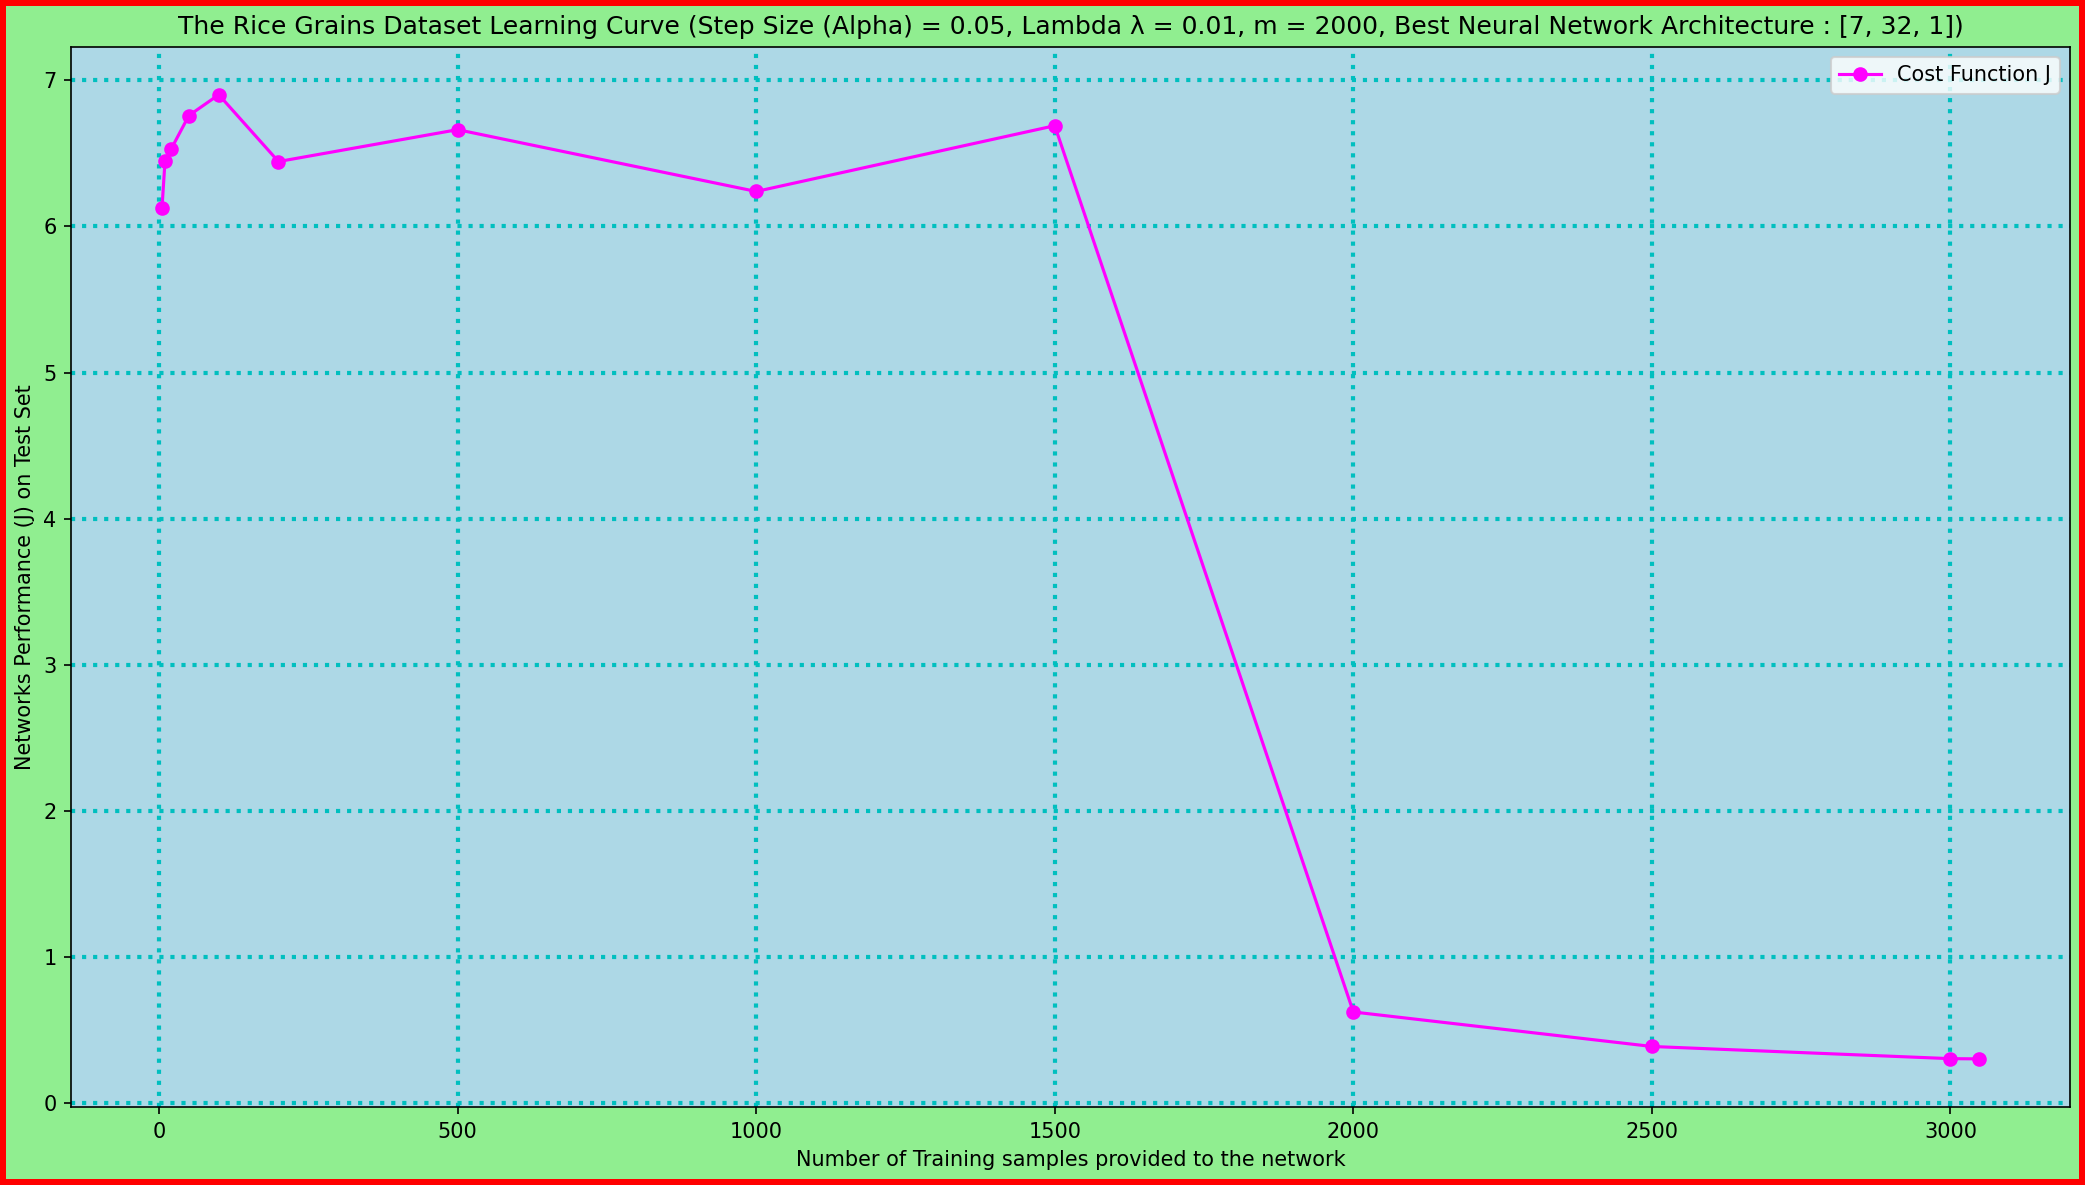

In [43]:
#### Final Project - Mohan Kumar Paramasivan - Dataset 3 ####
#### The Rice Grains Dataset ####
#### Algorithm 1 - Neural Networks ####
#### Extra Credit Question 1 ####

import matplotlib.pyplot as plt

#### Best architecture for The Rice Grains Dataset
layer_sizes = [7, 32, 1]
#### Step size value alpha = 0.05
alpha = 0.05
#### Regularization parameter lambda
lambda_ = 0.01

#### The Rice Grains Dataset has 3810 records : 80% records for training instances (3048 records) and 20% records for testing instances (762 records)
X_train_full = X_Rice[:3048]
#### select first 3048 rows for training set from Parkinsons Disease Detection dataset
X_test = X_Rice[3048:]
#### selects the remaining rows for test set from Parkinsons Disease Detection dataset
y_train_full = Y_Rice[:3048]
#### select first 3048 rows for training set from Parkinsons Disease Detection dataset
y_test = Y_Rice[3048:]
#### selects the remaining rows for test set from Parkinsons Disease Detection dataset

##### Normalizes the training and testing dataset
X_train_full, X_test = normalize(X_train_full, X_test)

#### Training size - Number of training examples increases progressively
training_sizes = [5, 10, 20, 50, 100, 200, 500, 1000, 1500, 2000, 2500, 3000, 3048]

#### Initialize a cost function list with empty values. J_value is used to store the average of the cost function for each training size
J_values = []

for size in training_sizes:
    #### for each training size iterate the for loop
    #### Picks the subset of training instances based on the training size
    X_subset = X_train_full[:size]
    y_subset = y_train_full[:size]


    #### Initialize random weights for each layer of the neural network
    Thetas = initialize_weights(layer_sizes)
    #### Trains the neural network by repeating the forward and backward propagation m times for the subset of the training instances
    Thetas = train(X_subset, y_subset, Thetas, alpha, lambda_, m = 2000)

    #### Initialize the J_list as a empty list for test set
    J_list = []
    for j, (x, y) in enumerate(zip(X_test, y_test)):
        _, J = forward_propagation(x, np.array([y]), Thetas, j)
        #### obtaining the cost function from the forward propagatgion function for the test set
        J_list.append(J)
        #### repeating the cost function and adding the cost function value result for each test instance to J_list list

    #### Calculate the mean value of cost function for each training size and corresponding test size
    J_values.append(np.mean(J_list))
    print(f'Size: {size}, J: {np.mean(J_list):.5f}')

#### plot
plt.figure(figsize=(14,8), dpi=150.0, facecolor='lightgreen', edgecolor='red', linewidth=5.0, frameon=True, layout='tight')
plt.plot(training_sizes, J_values,  marker='o', color='magenta', label='Cost Function J')
plt.xlabel('Number of Training samples provided to the network')
plt.ylabel('Networks Performance (J) on Test Set')
plt.title('The Rice Grains Dataset Learning Curve (Step Size (Alpha) = 0.05, Lambda λ = 0.01, m = 2000, Best Neural Network Architecture : [7, 32, 1])')
plt.grid(True, axis='both', color='c', linestyle=':', linewidth=2.0, alpha=1.0)
plt.legend()
plt.gca().set_facecolor('lightblue')
plt.savefig('The_Rice_Grains_Dataset_Learning_curve.pdf')
plt.show()

In [45]:
#### Final Project - Mohan Kumar Paramasivan - Dataset 4 ####
#### The Credit Approval Dataset ####
#### Algorithm 2 : K-Nearest Neighbour (K-NN) Algorithm ####
#### Extra Credit Question 1 ####

import pandas as pd
import numpy as np

credit_dataset = pd.read_csv("C:/Users/mohan/OneDrive/Desktop/UMass Amhers MSCS/Spring 2026 - Machine Learning/Final Project/Final_Project_CMPSCI_589_Spring2026_Supporting_Files/Final_Project_CMPSCI_589_Spring2026_Supporting_Files/credit_approval.csv", header = 0)
credit_dataset = credit_dataset.dropna()

X_credit_raw = credit_dataset.drop(columns=['label'])
X_credit_encoded = pd.get_dummies(X_credit_raw)
X_credit = np.array(X_credit_encoded, dtype=float)
Y_credit = np.array(credit_dataset['label'].values, dtype=int)


print('Credit Approval Dataset shape:', X_credit.shape, Y_credit.shape)
print('Number of features:', X_credit.shape[1])
credit_dataset.head()

Credit Approval Dataset shape: (653, 46) (653,)
Number of features: 46


,attr1_cat,attr2_num,attr3_num,attr4_cat,attr5_cat,attr6_cat,attr7_cat,attr8_num,attr9_cat,attr10_cat,attr11_cat,attr12_cat,attr13_cat,attr14_num,attr15_num,label
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1,f,g,202,0,1
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6,f,g,43,560,1
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0,f,g,280,824,1
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5,t,g,100,3,1
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0,f,s,120,0,1


In [47]:
#### Final Project - Mohan Kumar Paramasivan - Dataset 4 ####
#### The Credit Approval Dataset ####
#### Algorithm 2 : K-Nearest Neighbour (K-NN) Algorithm ####
#### Extra Credit Question 1 ####


#### KNN calculation function from HW 1 ####

import numpy as np

def knn_calculation(x_train_norm, y_train, X, k):

    distance = np.sqrt(np.sum((x_train_norm - X)**2, axis = 1))
    #### knn algorthim hyperparameter (distance k) is calculated based on Euclidean Distance ####

    #### argsort(distance) = returns the indices sorted in ascending order ####
    #### [:k] = picks only the top k nearest neighbours from the ordered indices ####
    distance_sort = np.argsort(distance)[:k] 

    #### y_train[distance_sort] = Picks the y labels for the indices selected in previous step   ####
    k_labels_indices = y_train[distance_sort]

    #### bincount(k_labels_indices) = counts the occurrences of each integer label ####
    #### argmax() = returns the index with the highest count ####
    prediction = np.bincount(k_labels_indices).argmax()

    return prediction

In [49]:
#### Final Project - Mohan Kumar Paramasivan - Dataset 4 ####
#### The Credit Approval Dataset ####
#### Algorithm 2 : K-Nearest Neighbour (K-NN) Algorithm ####
#### Extra Credit Question 1 ####


#### cross_validate_knn created based on cross_validate_rf from homework 3 specifically for KNN algorithm ####
#### k is chosen as 10 based on final project requirement (Use stratified cross-validation with k = 10) ####
def cross_validate_knn(X, y, k_neighbors, k=10):
    
    folds = create_stratified_folds(X, y, k)
    #### creates num_folds = 10 stratified folds of the dataset ####
    
    #### initial empty list created for accuracy_scores, f1_scores for both training and testing instances ####
    train_accuracy_scores = []
    test_accuracy_scores = []
    train_f1_scores = []
    test_f1_scores = []

    #### the for loop iterates for each fold ####  
    for i in range(k):
        
        #### the selected fold is choosen as the test indices ####
        #### the values in the folds are converted in to numpy array ####
        test_indices  = np.array(folds[i])

        #### for j in range(k) for j != i : it picks the rest of the folds other than the test fold for training indices ####
        #### the values in the folds are converted in to numpy array ####
        train_indices = np.array([idx for j in range(k) if j != i for idx in folds[j]])
        
        #### divides the training indices into X_train and y_train ####
        X_train, y_train = X[train_indices], y[train_indices]
        #### divides the testing indices into X_test and y_test ####
        X_test,  y_test  = X[test_indices],  y[test_indices]

        ##### Normalizes the training and testing data based on the Normalize function created in HW 4 ####
        X_train, X_test = normalize(X_train, X_test)
        

        #### predictions on training set ####
        y_pred_train = np.array([knn_calculation(X_train, y_train, x, k_neighbors) for x in X_train])
        #### predictions on test set ####
        y_pred_test = np.array([knn_calculation(X_train, y_train, x, k_neighbors) for x in X_test])

        #### Calculates and stores the performance metrics on the k-1 folds (training instances) ####
        train_accuracy_scores.append(accuracy(y_train, y_pred_train))
        train_f1_scores.append(f1_score(y_train, y_pred_train))
        #### Calculates and stores the performance metrics on the kth fold (test instances) ####
        test_accuracy_scores.append(accuracy(y_test, y_pred_test))
        test_f1_scores.append(f1_score(y_test, y_pred_test))

        
    return {
        'Train Accuracy': round(float(np.mean(train_accuracy_scores)), 6),
        'Test Accuracy':  round(float(np.mean(test_accuracy_scores)), 6),
        'Train F1 Score': round(float(np.mean(train_f1_scores)), 6),
        'Test F1 Score':  round(float(np.mean(test_f1_scores)), 6)
    }

In [53]:
#### Final Project - Mohan Kumar Paramasivan - Dataset 4 ####
#### The Credit Approval Dataset ####
#### Algorithm 2 : K-Nearest Neighbour (K-NN) Algorithm ####
#### Extra Credit Question 1 ####

#### convert Y_credit from float to int ####
#### np.bincount(k_labels_indices) in knn_calculation function will work only on int and not float ####
Y_credit_int = Y_credit.astype(int)

#### K-NN algorithm hyperparameter k is assigned odd value between 1 to 51 incrementing by 2 ####
k_values = range(1, 52, 2)  #class range(start, stop, step) 

#### initializing empty list to store average accuracy of testing and training instances ####
train_means = []
test_means = []
train_stds = []
test_stds = []
#### initializing empty list to store average f1 score of testing and training instances ####
train_f1_means = []
test_f1_means = []
train_f1_stds = []
test_f1_stds = []

#### for loop iterates for each k value ####
for k in k_values:
    print(f'k = {k}')
    #### initializing empty list to store training and testing accuracy for each k value ####
    train_accuracies = []
    test_accuracies = []
    #### initializing empty list to store training and testing f1 score for each k value ####
    train_f1s = []
    test_f1s = []

    #### HW 1 Guidelines : For each value of k, you should run the process described above 20 times ####
    for run in range(20):
        #### np.random.permutation : Generates a random ordering of the indices for all records of Credit approval dataset ####
        indices = np.random.permutation(len(X_credit))
        #### Shuffled features of Credit approval dataset ####
        X_shuffled = X_credit[indices]
        #### Shuffled labels of Credit approval dataset ####
        Y_shuffled = Y_credit_int[indices]
        
        #### Calling the cross_validate_knn function defined in previous step ####
        result = cross_validate_knn(X_shuffled, Y_shuffled, k)        

        #### The Accuracy and F1 Score are added to the list initialized earlier ####
        train_accuracies.append(result['Train Accuracy'])
        test_accuracies.append(result['Test Accuracy'])
        train_f1s.append(result['Train F1 Score'])
        test_f1s.append(result['Test F1 Score'])

    #### The mean and std deviation of Accuracy for all 20 iterations are added to the list initialized earlier ####
    train_means.append(np.mean(train_accuracies))
    test_means.append(np.mean(test_accuracies))
    train_stds.append(np.std(train_accuracies))
    test_stds.append(np.std(test_accuracies))

    #### The mean and std deviation of F1 Score for all 20 iterations are added to the list initialized earlier ####
    train_f1_means.append(np.mean(train_f1s))
    test_f1_means.append(np.mean(test_f1s))
    train_f1_stds.append(np.std(train_f1s))
    test_f1_stds.append(np.std(test_f1s))

    #### [-1] : last value added to the list ####
    #### prints the last value for accuracy and f1 score for current k value ####
    print(f'Train Accuracy: {train_means[-1]:.6f}')
    print(f'Test Accuracy:  {test_means[-1]:.6f}')
    print(f'Train F1 Score: {train_f1_means[-1]:.6f}')
    print(f'Test F1 Score:  {test_f1_means[-1]:.6f}')

k = 1
Train Accuracy: 1.000000
Test Accuracy:  0.812878
Train F1 Score: 1.000000
Test F1 Score:  0.790530
k = 3
Train Accuracy: 0.912421
Test Accuracy:  0.855202
Train F1 Score: 0.902858
Test F1 Score:  0.838971
k = 5
Train Accuracy: 0.896205
Test Accuracy:  0.865877
Train F1 Score: 0.885382
Test F1 Score:  0.852247
k = 7
Train Accuracy: 0.891135
Test Accuracy:  0.868519
Train F1 Score: 0.879899
Test F1 Score:  0.854751
k = 9
Train Accuracy: 0.886150
Test Accuracy:  0.868212
Train F1 Score: 0.874619
Test F1 Score:  0.854343
k = 11
Train Accuracy: 0.884677
Test Accuracy:  0.866072
Train F1 Score: 0.872706
Test F1 Score:  0.851650
k = 13
Train Accuracy: 0.883690
Test Accuracy:  0.868349
Train F1 Score: 0.871707
Test F1 Score:  0.854322
k = 15
Train Accuracy: 0.882977
Test Accuracy:  0.864450
Train F1 Score: 0.870737
Test F1 Score:  0.850146
k = 17
Train Accuracy: 0.878483
Test Accuracy:  0.860380
Train F1 Score: 0.866052
Test F1 Score:  0.846236
k = 19
Train Accuracy: 0.872970
Test Accur

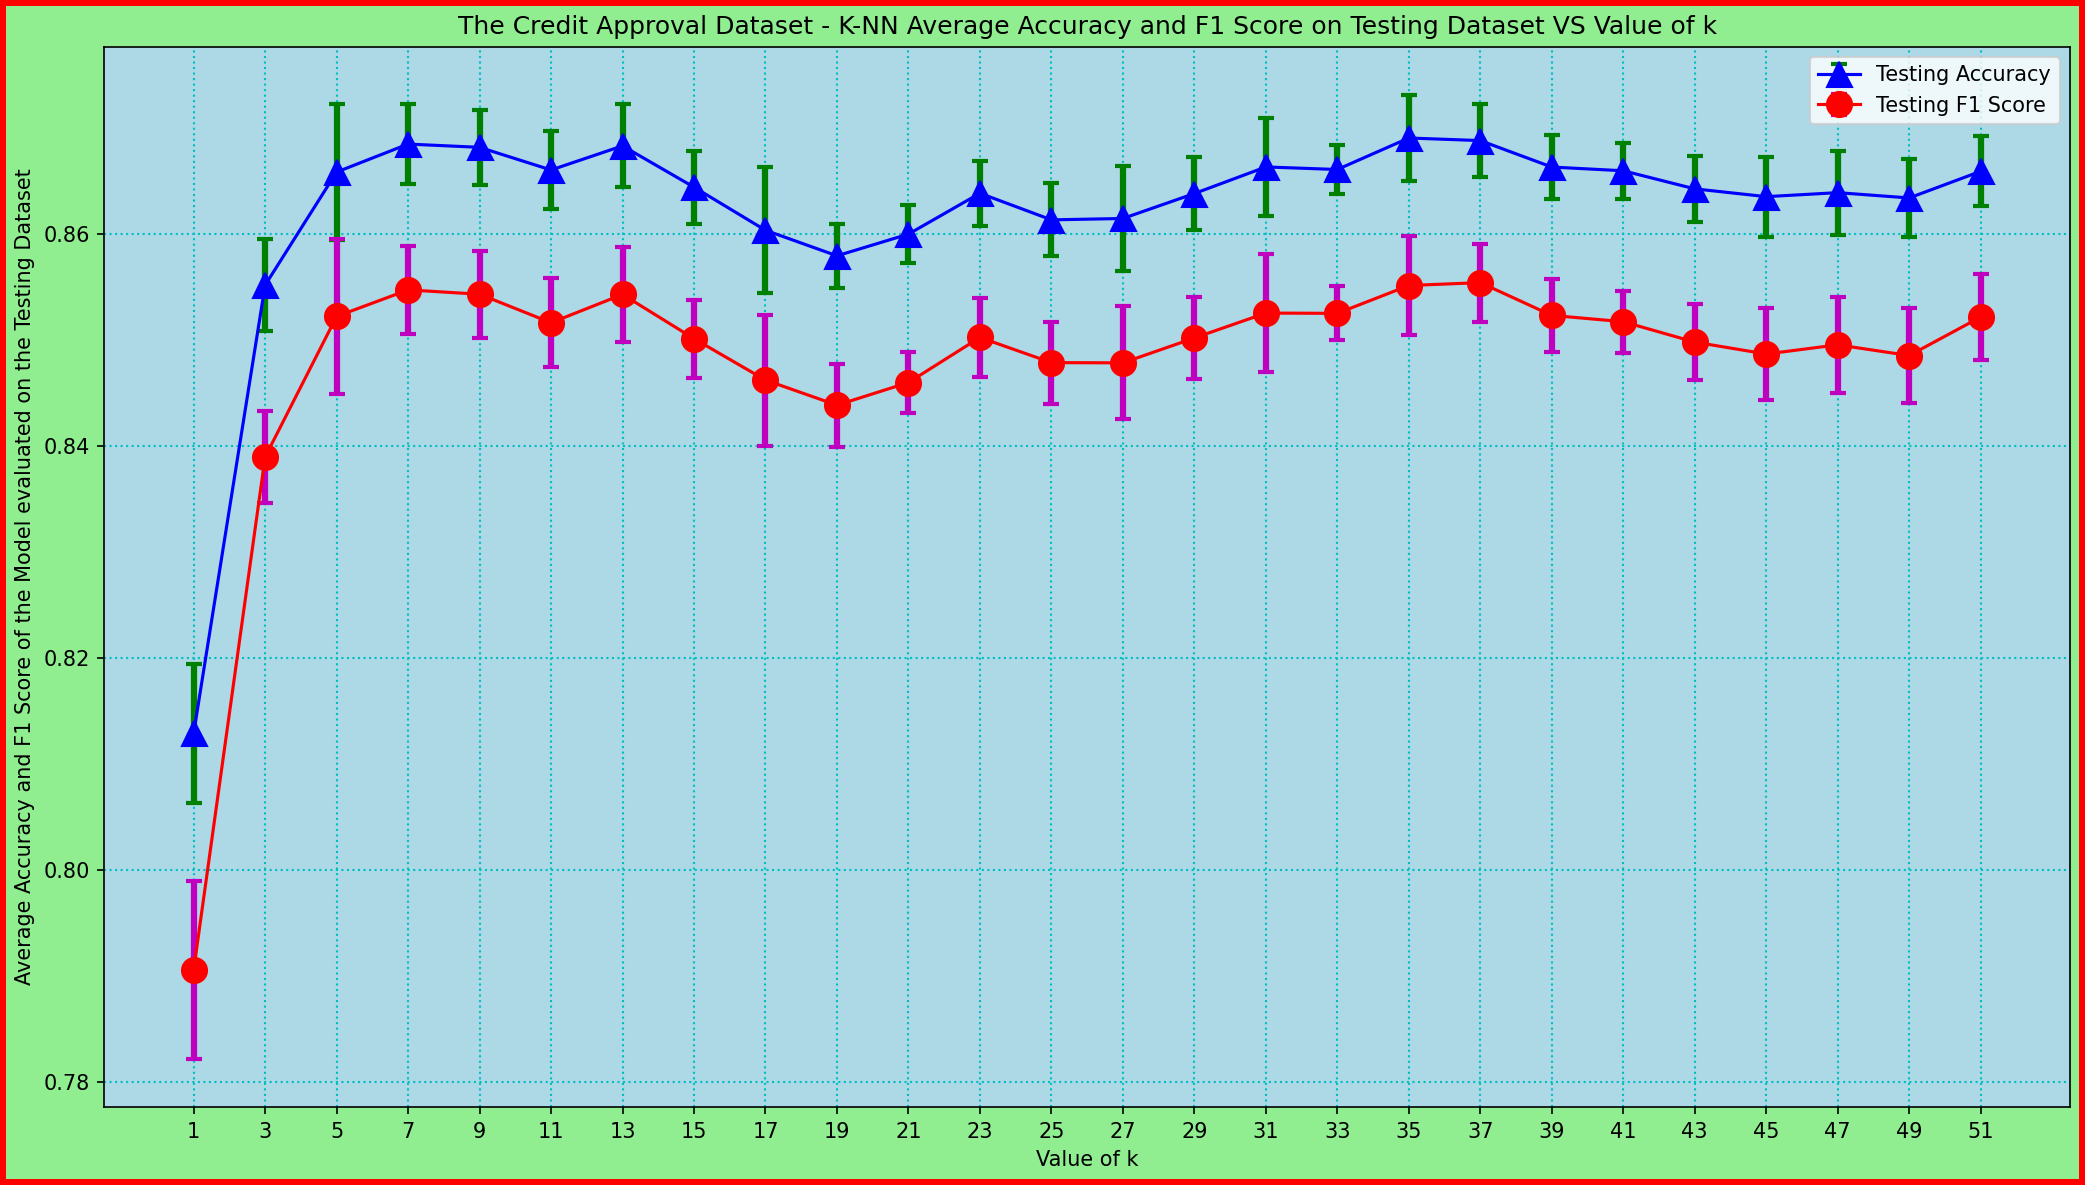

In [55]:
#### Final Project - Mohan Kumar Paramasivan - Dataset 4 ####
#### The Credit Approval Dataset ####
#### Algorithm 2 : K-Nearest Neighbour (K-NN) Algorithm ####
#### Extra Credit Question 1 ####

#### The average accuracy of models evaluated on the testing set, given that particular value of k. ####
#### Created based on HW 1 Graphs ####

plt.figure(figsize = (14,8), dpi = 150.0, facecolor = 'lightgreen', edgecolor = 'red', linewidth = 5.0, frameon = True, layout = 'tight')

plt.errorbar(
    x = k_values,
    y = test_means,
    xerr = None,
    yerr = test_stds,
    fmt = '^-',
    label = 'Testing Accuracy',
    markersize = 12.0,
    color = 'b',
    capsize = 4,
    capthick = 2, 
    ecolor = 'g',
    elinewidth = 3.0, 
    barsabove = False, 
    errorevery = 1
)

plt.errorbar(
    x = k_values, 
    y = test_f1_means, 
    xerr = None, 
    yerr = test_f1_stds,
    fmt = 'o-', 
    label = 'Testing F1 Score', 
    markersize = 12.0, 
    color = 'r',
    capsize = 4, 
    capthick = 2, 
    ecolor = 'm', 
    elinewidth = 3.0, 
    barsabove = False, 
    errorevery = 1
)

plt.xticks(k_values)
plt.xlabel("Value of k")
plt.ylabel("Average Accuracy and F1 Score of the Model evaluated on the Testing Dataset")
plt.title("The Credit Approval Dataset - K-NN Average Accuracy and F1 Score on Testing Dataset VS Value of k")
plt.grid(True, axis = 'both', color = 'c', linestyle = ':', linewidth = 1.0, alpha = 1.0)
plt.legend()
plt.gca().set_facecolor('lightblue')
plt.savefig('Credit_Approval_kNN_Testing_Performance_vs_k.pdf')

plt.show()